# Prognose des Besuchsvolumens der Notaufnahme mit exponentieller Glättung (PROC ESM)


## Zusammenfassung

Ein mittelgroßes Krankenhaussystem benötigt eine Jahresprognose des monatlichen Besuchsvolumens der Notaufnahme (ED), um die Personalplanung der Pflegekräfte und die Bettenkapazität vor dem winterlichen Anstieg der Atemwegserkrankungen zu planen. Dieses Notebook erstellt eine synthetische vierjährige monatliche ED-Erfassung (48 Monate, Jan. 2021 - Dez. 2024) und passt ein multiplikatives saisonales Winters-Modell mit **PROC ESM** an, um eine 12-Monats-Prognose mit 95%-Vorhersageintervallen zu erstellen.

Das angepasste Modell bildet die Reihe gut ab: der **RMSE innerhalb der Stichprobe liegt bei etwa 320 Besuchen** und der **MAPE bei 4,16%**, sodass der typische monatliche Fehler unter 5% des Volumens liegt. Die Prognose projiziert die vertraute saisonale Form ins Jahr 2025 - eine Spitze von Dezember bis Februar nahe **7.300-7.800 Besuchen/Monat** und ein Spätsommertief nahe **5.800-5.900** - mit Vorhersagebändern, die sich mit zunehmendem Horizont verbreitern. Diese Zahlen und die dahinterliegenden Glättungsgewichte werden direkt aus den unten stehenden Ausgabedatensätzen der Prozedur abgelesen.


## Datenquellen

| Datensatz | Zeilen | Granularität | Schlüsselvariablen | Beschreibung |
|---------|------|-------|---------------|-------------|
| `ed_census` | 48 | Eine Zeile pro Kalendermonat, Jan. 2021 - Dez. 2024 | `month` (monatliches SAS-Datum), `ed_visits` (ganzzahlige monatliche ED-Besuchszahl) | Synthetisches monatliches Besuchsvolumen der Notaufnahme für ein mittelgroßes Krankenhaussystem. Erzeugt mit einem aufwärts gerichteten Wachstumstrend (~3% jährlich), einem multiplikativen saisonalen Zyklus mit Höhepunkt in der winterlichen Atemwegssaison (Dez.-Feb.) und einem Tiefpunkt im Spätsommer, plus log-normalem Rauschen, sodass die saisonale Amplitude mit dem steigenden Niveau skaliert. |


# Prognose des Besuchsvolumens der Notaufnahme mit PROC ESM

Kapazitätsplaner müssen wissen, wie viele ED-Besuche in jedem Monat zu erwarten sind, damit sie Pflegekräfte einteilen, Flexbetten bereithalten und Atemwegsvorräte vor dem Winteranstieg bereitstellen können. Das ED-Volumen ist eine klassische saisonale Zeitreihe: es wächst langsam von Jahr zu Jahr, erreicht seinen Höhepunkt während der Atemwegssaison von Dezember bis Februar und ebbt im Spätsommer ab, und die Größe des saisonalen Ausschlags wächst mit dem steigenden Grundvolumen. Genau diese multiplikative saisonale Struktur soll die multiplikative Winters-Methode in **PROC ESM** erfassen.

In diesem Notebook:

1. Erzeugen wir eine realistische vierjährige monatliche ED-Erfassung mit Trend, multiplikativer Saisonalität und Rauschen.
2. Visualisieren wir die Reihe, um ihre multiplikative saisonale Struktur zu bestätigen.
3. Passen wir ein multiplikatives Winters-Modell mit PROC ESM an und lesen dessen Glättungsgewichte und Anpassungsstatistiken aus den Ausgabedatensätzen ab.
4. Erstellen wir eine 12-Monats-Prognose mit 95%-Vorhersageintervallen und interpretieren die betrieblichen Auswirkungen.


## Schritt 1 - Erzeugen der synthetischen monatlichen ED-Erfassung

Wir erstellen 48 monatliche Beobachtungen von Januar 2021 bis Dezember 2024. Das erwartete Volumen jedes Monats ist ein Basisniveau, das um etwa 3% pro Jahr wächst, multipliziert mit einem saisonalen Index (am höchsten im Hochwinter, am niedrigsten im Spätsommer), dann gestört durch log-normales Rauschen, sodass die zufällige Variation mit dem Niveau skaliert. `intnx` rückt das monatlich ausgerichtete Datum um eine Periode pro Zeile vor, und `streaminit` macht die Ziehung reproduzierbar.


In [1]:
DATEN ed_census;
    AUFRUFEN streaminit(20240531);
    /* Monatlicher Saisonindex: Spitzen Dez-Feb (Grippe/RSV), Tiefpunkte Aug-Sep */
    FELD seas{12} _temporary_
        (1.18 1.14 1.05 0.97 0.93 0.90 0.92 0.86 0.88 0.97 1.06 1.14);
    format month yymmn6.;
    AUSFÜHRUNG i = 1 BIS 48;
        month = intnx('month', '01JAN2021'd, i - 1);
        m = month(month);
        /* Basis ~6000 Besuche/Monat, ~3% Wachstum pro Jahr */
        level = 6000 * (1.03 ** ((i - 1) / 12));
        /* Multiplikative Saisonalität + niveauskaliertes lognormales Rauschen */
        noise = EXP(rand('normal', 0, 0.035));
        ed_visits = round(level * seas{m} * noise);
        AUSGABE;
    ENDE;
    BEHALTEN month ed_visits;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=ed_census(obs=14) noobs BEZEICHNUNG;
    BEZEICHNUNG month = 'Monat' ed_visits = 'Notaufnahmebesuche';
    TITEL 'Erste 14 Monate des synthetischen Notaufnahme-Besuchsvolumens';
AUSFÜHREN;

                             Erste 14 Monate des synthetischen Notaufnahme-Besuchsvolumens                              

 Monat  Notaufnahmebesuche
202101                7103
202102                6835
202103                6668
202104                5611
202105                5816
202106                5383
202107                5586
202108                5283
202109                5161
202110                6109
202111                6451
202112                6730
202201                6847
202202                7213

... 34 more observations (showing 14 of 48)




NOTE: DATA ed_census


NOTE: Wrote ed_census (48 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ed_census

NOTE: PROC PRINT completed: 14 observations printed, 2 variables


Die ersten Monate bestätigen den Entwurf: das Volumen beginnt nahe 7.100 in der Spitze im Januar 2021, fällt über Frühling und Sommer zu seinem Tiefpunkt im August-September und steigt dann wieder in den nächsten Winter. Bis Januar 2022 ist die Spitze auf etwa 6.800-7.200 gestiegen, was das ~3%-jährliche Wachstum widerspiegelt, das dem saisonalen Zyklus überlagert ist.


## Schritt 2 - Visualisieren der Reihe

Vor der Modellierung zeichnen wir die Rohreihe, um die erwartete Struktur zu bestätigen: einen sanften Aufwärtstrend mit einer sich wiederholenden jährlichen Spitze in jedem Winter, deren Amplitude sich im Laufe der Zeit verbreitert. Ein sich verbreiternder saisonaler Ausschlag ist das Kennzeichen eines *multiplikativen* saisonalen Prozesses und sagt uns, welches ESM-Modell zu wählen ist.


                             Erste 14 Monate des synthetischen Notaufnahme-Besuchsvolumens                              




NOTE: PROC SGPLOT data=ed_census

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


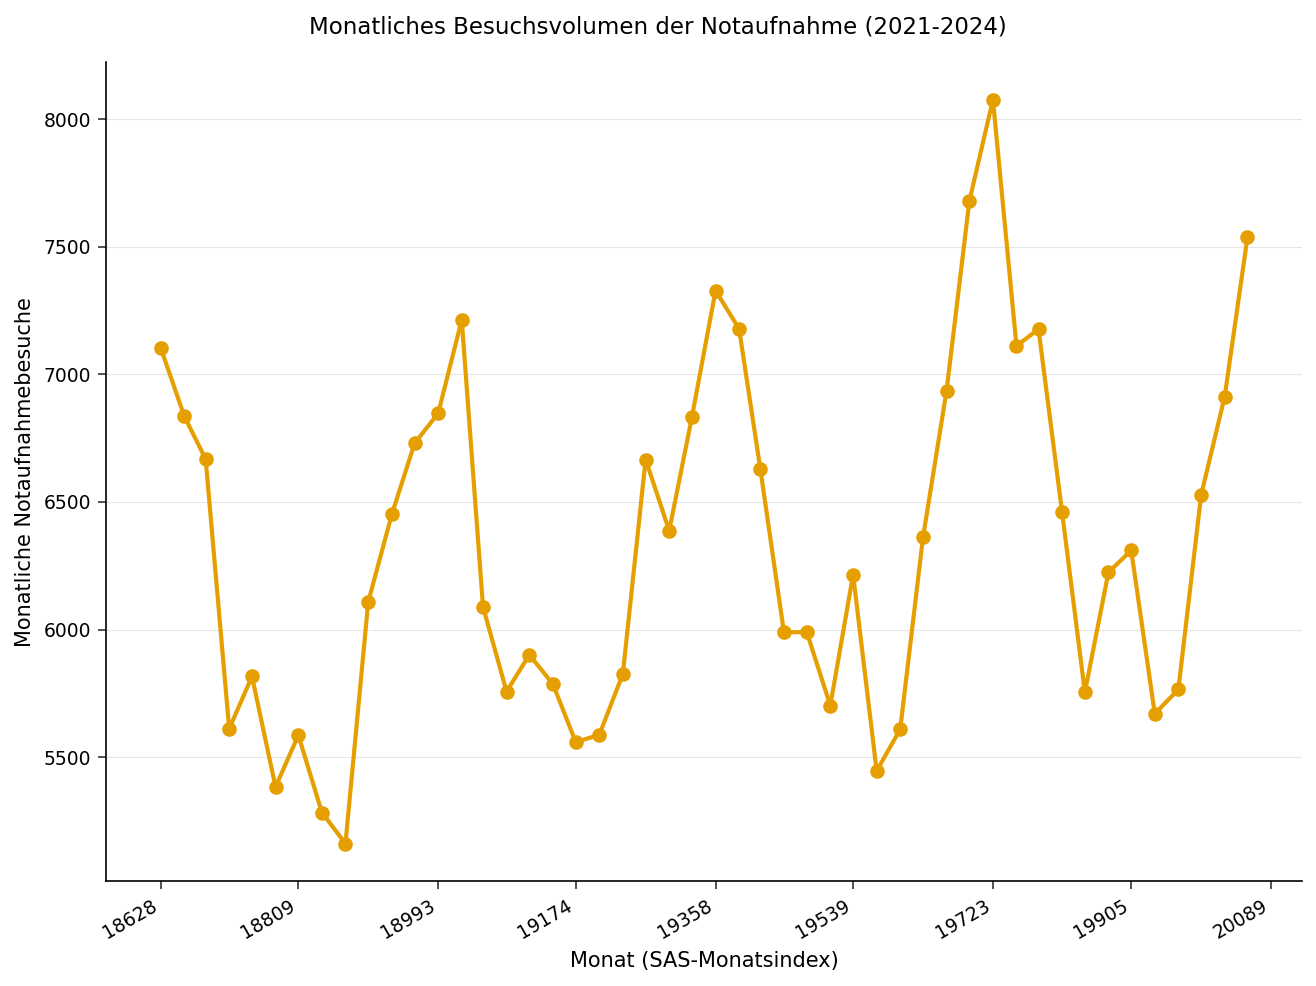

In [2]:
PROZEDUR SGPLOT DATEN=ed_census;
    SERIES x=month y=ed_visits / MARKERS
        MARKERATTRS=(SYMBOL=circlefilled)
        LINEATTRS=(thickness=2);
    XAXIS BEZEICHNUNG='Monat (SAS-Monatsindex)';
    YAXIS BEZEICHNUNG='Monatliche Notaufnahmebesuche' grid;
    TITEL 'Monatliches Besuchsvolumen der Notaufnahme (2021-2024)';
AUSFÜHREN;

Das Diagramm zeigt vier saubere jährliche Zyklen. Jede Winterspitze liegt etwas höher als die vorherige und steigt von etwa 7.100 im Jahr 2021 auf etwa 8.100 bei der Spitze 2024, während die Sommertiefpunkte bescheidener ansteigen - der saisonale Ausschlag wächst mit dem Niveau. Diese sich verbreiternde Amplitude ist das Kennzeichen der multiplikativen Saisonalität und rechtfertigt `MODEL=WINTERS` (Winters multiplikativ) im nächsten Schritt.


## Schritt 3 - Anpassen des multiplikativen Winters-Modells

Wir passen die multiplikative saisonale Winters-Glättung an die vollständige 48-monatige Historie an. Die `ID`-Anweisung deklariert `month` als Zeitindex mit einem `MONTH`-Intervall, und die `FORECAST`-Anweisung fordert `MODEL=WINTERS` mit `LEAD=12` an, um ein Jahr vorauszuprojizieren. Wir erfassen drei Ausgabedatensätze:

- `OUT=` - die historische Reihe mit angehängter Prognose (eine `ed_visits`-Spalte), wobei die Zeit-ID über den Prognosehorizont erweitert wird - ideal zum Plotten.
- `OUTFOR=` - die Prognosekomponenten pro Periode: Punktprognose (`PREDICT`) und die unteren/oberen Vorhersagegrenzen.
- `OUTSUM=` - die Anpassungsstatistiken des Modells (RMSE, MAE, MAPE, AIC) und Glättungsgewichte, in einer einzigen Zusammenfassungszeile.

`ALPHA=0.05` liefert 95%-Vorhersagegrenzen, angemessen für Risikomargen der Kapazitätsplanung. `PRINT=(STATISTICS)` gibt die Anpassungsstatistiken und Glättungsgewichte im Listing wieder.


In [3]:
PROZEDUR esm DATEN=ed_census
        LEAD=12
        out=ed_with_forecast
        outfor=esm_forecast
        outsum=esm_summary
        DRUCKEN=(statistics);
    id month interval=month;
    forecast ed_visits / MODELL=winters ALPHA=0.05;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=esm_summary noobs BEZEICHNUNG;
    BEZEICHNUNG rmse='RMSE' mae='MAE' mape='MAPE'
          ALPHA='Niveau (Alpha)' beta='Trend (Beta)' gamma='Saison (Gamma)';
    VAR rmse mae mape ALPHA beta gamma;
    TITEL 'Winters-Anpassungsstatistiken und Glättungsgewichte';
AUSFÜHREN;

                             Erste 14 Monate des synthetischen Notaufnahme-Besuchsvolumens                              


Exponential Smoothing Forecast for ed_visits
Method: WINTERS
Number of Observations: 48
Forecast Periods: 12

Fit Statistics:
  RMSE     = 320.4349
  MAE      = 264.4440
  MAPE     = 4.1597
  MSE      = 102678.4971
  AIC      = 421.4169

Smoothing Weights:
  ALPHA      = 0.3000
  BETA       = 0.1000
  GAMMA      = 0.1000

Forecasts:
  Period     Predict        
  1          7822.1805      
  2          7538.7511      
  3          7291.7885      
  4          6262.7158      
  5          6396.7222      
  6          6039.1562      
  7          6235.5688      
  8          5867.3108      
  9          5801.6677      
  10         6803.9608      
  11         7172.6105      
  12         7566.8263      



                                  Winters-Anpassungsstatistiken und Glättungsgewichte                                   

          RMSE            MAE         MA


NOTE: PROC ESM data=ed_census

NOTE: Using Python for ESM estimation
NOTE: Output dataset ED_WITH_FORECAST created with 60 observations.
NOTE: Output dataset ESM_FORECAST created with 60 observations.
NOTE: PROC PRINT data=esm_summary

NOTE: PROC PRINT completed: 1 observations printed, 6 variables


Die `OUTSUM=`-Zeile und die gedruckten Statistiken stimmen überein: die multiplikative Winters-Anpassung erreicht innerhalb der Stichprobe einen **RMSE von 320,4 Besuchen**, einen **MAE von 264,4** und einen **MAPE von 4,16%** - ein typischer monatlicher Fehler deutlich unter 5% des Volumens, was für die Personalplanung komfortabel genau ist. Die Glättungsgewichte sind **alpha = 0,30** (Niveau), **beta = 0,10** (Trend) und **gamma = 0,10** (Saison). Das moderate Niveaugewicht lässt die Basislinie mit dem Wachstum der Patientenpopulation nach oben driften, während die kleinen Trend- und Saisongewichte widerspiegeln, dass die Wachstumsrate und die Form des Winteranstiegs von Jahr zu Jahr stabil sind und nicht von Monat zu Monat überinterpretiert werden sollten.

> Hinweis: dies sind Anpassungsstatistiken *innerhalb der Stichprobe*, berechnet über die Schätzstichprobe, nicht ein Out-of-Sample-Holdout. Sie quantifizieren, wie genau das Modell die Historie nachbildet, an die es angepasst wurde.


## Schritt 4 - Zusammenstellen und Tabellieren der 12-Monats-Prognose

Der `OUTFOR=`-Datensatz enthält die Punktprognose und Vorhersagegrenzen für jede Periode, während der `OUT=`-Datensatz die Zeit-ID sauber über den Prognosehorizont erweitert trägt. Wir richten die beiden nach Beobachtungsreihenfolge aus, um die Prognosedaten an die Vorhersagegrenzen anzuhängen, und behalten dann nur die 12 Prognosemonate. Dies sind die Zahlen, nach denen ein Personalausschuss handeln würde.


In [4]:
/* OUT= trägt die Prognosehorizont-Daten; OUTFOR= trägt die
   Prognosegrenzen. Nach Beobachtungsreihenfolge ausrichten, um die Daten
   an die Grenzen zu heften, dann nur die 12 Prognosemonate behalten. */
DATEN out_idx;
    FESTLEGEN ed_with_forecast;
    row = _n_;
    UMBENENNEN month = fdate ed_visits = series_value;
AUSFÜHREN;

DATEN for_idx;
    FESTLEGEN esm_forecast;
    row = _n_;
    UMBENENNEN ed_visits = observed;
    BEHALTEN row observed predict LOWER UPPER;
AUSFÜHREN;

DATEN forecast_path;
    ZUSAMMENFÜHREN out_idx for_idx;
    NACH row;
    format fdate yymmn6. series_value observed predict LOWER UPPER comma8.0;
AUSFÜHREN;

DATEN forecast_horizon;
    FESTLEGEN forecast_path;
    WO observed = .;   /* nur Prognosemonate (kein beobachteter Wert) */
    BEHALTEN fdate predict LOWER UPPER;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=forecast_horizon noobs BEZEICHNUNG;
    BEZEICHNUNG fdate   = 'Monat'
          predict = 'Prognose Besuche'
          LOWER   = '95% Untergrenze'
          UPPER   = '95% Obergrenze';
    TITEL '12-Monats-Prognose der Notaufnahmebesuche mit 95%-Prognosegrenzen';
AUSFÜHREN;

                           12-Monats-Prognose der Notaufnahmebesuche mit 95%-Prognosegrenzen                            

 Monat  Prognose Besuche  95% Untergrenze  95% Obergrenze
202501             7,822            7,194           8,450
202502             7,539            6,651           8,427
202503             7,292            6,204           8,380
202504             6,263            5,007           7,519
202505             6,397            4,992           7,801
202506             6,039            4,501           7,578
202507             6,236            4,574           7,897
202508             5,867            4,091           7,644
202509             5,802            3,918           7,686
202510             6,804            4,818           8,790
202511             7,173            5,090           9,256
202512             7,567            5,391           9,742




NOTE: DATA out_idx


NOTE: Read 60 rows from ed_with_forecast.
NOTE: Wrote out_idx (60 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA for_idx


NOTE: Read 60 rows from esm_forecast.
NOTE: Wrote for_idx (60 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA forecast_path

NOTE: Stream 1 processed 60 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 60 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote forecast_path (60 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA forecast_horizon


NOTE: Read 60 rows from forecast_path.
NOTE: Wrote forecast_horizon (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=forecast_horizon

NOTE: PROC PRINT completed: 12 observations printed, 4 variables


Die Prognose trägt die saisonale Signatur ins Jahr 2025 fort. Das Modell projiziert die Spitze im Januar 2025 auf etwa **7.822 Besuche** (95%-Intervall 7.194-8.450), lässt sie über den Frühling nach, erreicht das Spätsommertief nahe **5.802** im September (Intervall 3.918-7.686) und baut sich dann wieder zu einer Dezemberspitze von etwa **7.567** (Intervall 5.391-9.742) auf. Das Vorhersageband verbreitert sich stetig mit dem Horizont - das Intervall des nächsten Monats umfasst etwa +/-630 Besuche, während das des nächsten Dezember mehr als +/-2.000 umfasst - eine direkte Erinnerung daran, dass kurzfristige Pläne weitaus fester sind als die zum Jahresende.


## Schritt 5 - Plotten der Historie plus Prognose

Schließlich überlagern wir die Prognose über die beobachtete Historie, damit Planer die projizierte Winterspitze und das sich verbreiternde Unsicherheitsband bei zunehmendem Horizont sehen können. Wir teilen die ausgerichtete `forecast_path`-Reihe in die **beobachtete** Historie (durchgezogen) und die **12-Monats-Prognose** (gestrichelt) auf, sodass der Übergang klar ist, und zeichnen das 95%-Vorhersageband darunter. Die x-Achse ist der monatliche SAS-Datumsindex, der von links nach rechts von Jan. 2021 bis Dez. 2025 verläuft.


                           12-Monats-Prognose der Notaufnahmebesuche mit 95%-Prognosegrenzen                            




NOTE: DATA forecast_plot


NOTE: Read 60 rows from forecast_path.
NOTE: Wrote forecast_plot (60 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=forecast_plot

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


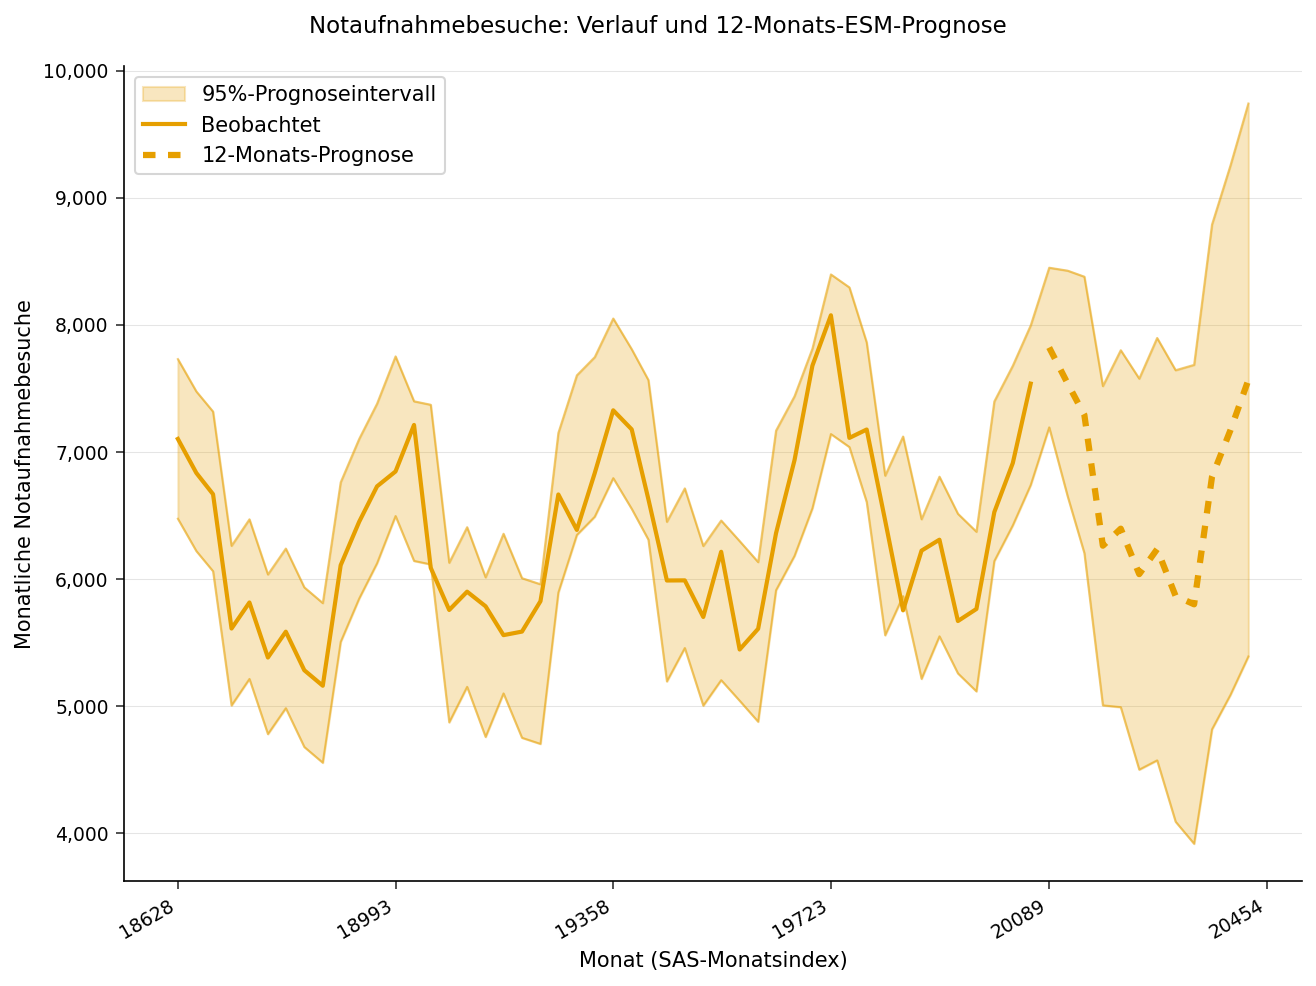

In [5]:
/* Die projizierte Reihe in beobachtete Historie und 12-Monats-Prognose
   aufteilen, damit sie unterschiedlich dargestellt werden, und das
   95%-Prognoseband aus dem ausgerichteten forecast_path-Datensatz überlagern. */
DATEN forecast_plot;
    FESTLEGEN forecast_path;
    WENN observed = . DANN fc_only = predict;   /* nur zukünftige Monate */
    SONST fc_only = .;
AUSFÜHREN;

PROZEDUR SGPLOT DATEN=forecast_plot;
    BAND x=fdate LOWER=LOWER UPPER=UPPER /
        legendlabel='95%-Prognoseintervall' TRANSPARENCY=0.5;
    SERIES x=fdate y=observed / LINEATTRS=(thickness=2)
        legendlabel='Beobachtet';
    SERIES x=fdate y=fc_only / LINEATTRS=(thickness=3 pattern=shortdash)
        legendlabel='12-Monats-Prognose';
    XAXIS BEZEICHNUNG='Monat (SAS-Monatsindex)';
    YAXIS BEZEICHNUNG='Monatliche Notaufnahmebesuche' grid;
    TITEL 'Notaufnahmebesuche: Verlauf und 12-Monats-ESM-Prognose';
AUSFÜHREN;

## Interpretation der Ergebnisse

Das multiplikative Winters-Modell zerlegt das ED-Volumen in ein langsam steigendes **Niveau**, einen nahezu flachen **Trend** und ein stabiles **saisonales** Muster. Die aus `OUTSUM=` abgelesenen Glättungsgewichte erzählen die Geschichte: ein moderates Niveaugewicht (alpha = 0,30) lässt die Basislinie mit dem Wachstum der Patientenpopulation nach oben driften, während kleine Trend- und Saisongewichte (beta = gamma = 0,10) widerspiegeln, dass die Wachstumsrate und die Form des Winteranstiegs von Jahr zu Jahr höchst stabil sind und nicht von Monat zu Monat überinterpretiert werden sollten.

Die **Anpassungsstatistiken** bestätigen, dass das Modell die Historie gut nachbildet: ein RMSE von etwa 320 Besuchen und ein MAPE von 4,16% bedeuten, dass der typische monatliche Fehler unter 5% des Volumens liegt. Betrieblich quantifizieren die **Prognosetabelle und das Bandplot** die Spitze von Dezember bis Februar, auf die die Notaufnahme hin planen sollte - etwa 7.300-7.800 Besuche in den Wintermonaten - und die 95%-Vorhersagegrenzen definieren einen umsichtigen Kapazitätsbereich: planen Sie die Kernbesetzung nach der Punktprognose und arrangieren Sie Flexabdeckung und Zusatzbetten in Richtung der oberen Grenze vorab. Das Intervall verbreitert sich mit dem Horizont, sodass der Plan des nächsten Monats weitaus fester ist als der des nächsten Dezember und aktualisiert werden sollte, sobald neue Ist-Werte eintreffen.

**Erweiterungen:** vergleichen Sie `MODEL=ADDWINTERS` (additive Saisonalität) mit der multiplikativen Anpassung, um die multiplikative Wahl zu bestätigen; wenden Sie `TRANSFORM=LOG` an, um Positivität zu erzwingen und die Varianz zu stabilisieren; oder fügen Sie eine `BY`-Anweisung hinzu, um mehrere Krankenhausstandorte in einem einzigen PROC ESM-Aufruf zu prognostizieren.
